# IntZ Example 11: Omega vs Redshift
**EPS Research — Cross-Epoch Science**

Plot omega vs redshift within the IntZ Tier-1 sample to look for internal redshift trends.

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'intz_corpus_v1b.json': 'https://zenodo.org/records/20453189/files/intz_corpus_v1b.json',
        'intz_corpus_v1b_flat.csv': 'https://zenodo.org/records/20453189/files/intz_corpus_v1b_flat.csv',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load IntZ corpus
with open('/home/david/Documents/RAG Project/Z=2 RAG/Zenodo/intz_corpus_v1b.json') as f:
    data = json.load(f)
galaxies = data['galaxies']
print(f"Loaded {len(galaxies)} galaxies")

Loaded 1292 galaxies


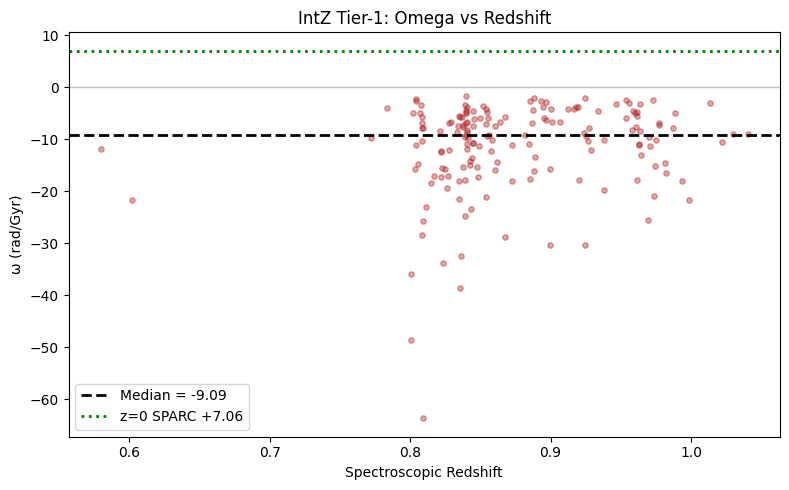

Spearman rho = 0.165, p = 0.033


In [3]:
t1 = [(g['redshift']['z_spec'],
         g['omega']['omega_value_rad_gyr'])
        for g in galaxies
        if g['omega']['omega_available']
        and g['omega']['omega_value_rad_gyr'] is not None]
z_t1, om_t1 = zip(*t1)

fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(z_t1, om_t1, c='firebrick', alpha=0.4, s=15)
ax.axhline(0, color='gray', ls='-', lw=1, alpha=0.5)
ax.axhline(np.median(om_t1), color='black', ls='--', lw=2,
           label=f'Median = {np.median(om_t1):.2f}')
ax.axhline(7.06, color='green', ls=':', lw=2, label='z=0 SPARC +7.06')
ax.set_xlabel('Spectroscopic Redshift')
ax.set_ylabel('ω (rad/Gyr)')
ax.set_title('IntZ Tier-1: Omega vs Redshift')
ax.legend()
plt.tight_layout()
plt.savefig('intz_nb11_omega_z.png', dpi=120)
plt.show()

# Spearman correlation
from scipy.stats import spearmanr
rho, p = spearmanr(z_t1, om_t1)
print(f"Spearman rho = {rho:.3f}, p = {p:.3f}")